In [24]:
import pandas as pd

# Load the dataset
file_path = 'dataset/claudette_train_merged.tsv'
data = pd.read_csv(file_path, sep='\t')

In [25]:
import matplotlib.pyplot as plt

In [26]:
data.head(4)

,id,document,label,label_type,text,label_indices
0,0,Mozilla,0,[],websites & communications terms of use,[0]
1,1,Mozilla,0,[],please read the terms of this entire document ...,[0]
2,2,Mozilla,1,['USE'],by accessing or signing up to receive communic...,[9]
3,3,Mozilla,0,[],our websites include multiple domains such as ...,[0]


In [27]:
len(data)

8354

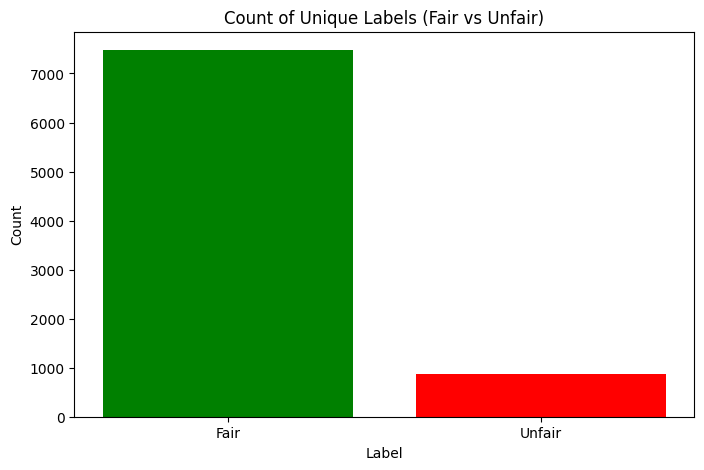

In [28]:
# Count the occurrences of each label
label_counts = data['label'].value_counts()

# Map the labels to their respective categories
label_mapping = {0: 'Fair', 1: 'Unfair'}
label_counts.index = label_counts.index.map(label_mapping)

# Plot the bar graph
plt.figure(figsize=(8, 5))
plt.bar(label_counts.index, label_counts.values, color=['green', 'red'])
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Count of Unique Labels (Fair vs Unfair)')
plt.show()

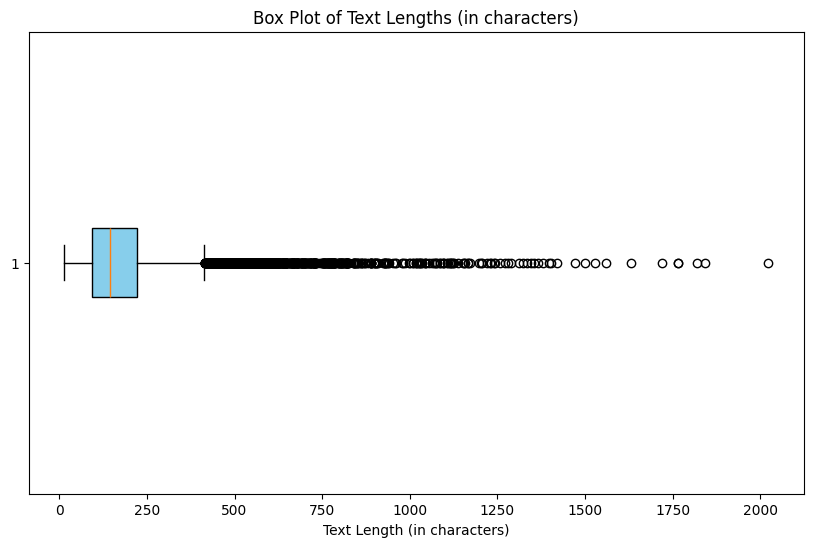

Descriptive Statistics for Text Lengths:
count    20417.000000
mean       179.817505
std        139.720220
min         13.000000
25%         94.000000
50%        145.000000
75%        222.000000
max       2023.000000
Name: text_length, dtype: float64


In [6]:
import matplotlib.pyplot as plt

# Calculate the length of each string in the "text" column
data['text_length'] = data['text'].apply(len)

# Calculate descriptive statistics for the text lengths
text_length_stats = data['text_length'].describe()

# Plot the box plot for the text lengths
plt.figure(figsize=(10, 6))
plt.boxplot(data['text_length'], vert=False, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.xlabel('Text Length (in characters)')
plt.title('Box Plot of Text Lengths (in characters)')
plt.show()

# Display the statistics as a table
print("Descriptive Statistics for Text Lengths:")
print(text_length_stats)

In [7]:
# Ensure the label column is of integer type
data['label'] = data['label'].astype(int)

# Filter rows where label is 1
filtered_data = data[data['label'] == 1]
print(filtered_data)

len(filtered_data)

          id file_name  label     label_type  \
2          2   Mozilla      1        ['USE']   
37        37   Mozilla      1         ['CR']   
49        49   Mozilla      1        ['TER']   
57        57   Mozilla      1        ['LTD']   
58        58   Mozilla      1        ['LTD']   
...      ...       ...    ...            ...   
20408  20408    Syncme      1  ['CR', 'TER']   
20409  20409    Syncme      1  ['CR', 'TER']   
20410  20410    Syncme      1  ['CR', 'TER']   
20414  20414    Syncme      1         ['CH']   
20415  20415    Syncme      1        ['USE']   

                                                    text label_indices  
2      by accessing or signing up to receive communic...           [9]  
37     you understand and agree that mozilla reserves...           [3]  
49     we may suspend or terminate your access to our...           [8]  
57     except as required by law , mozilla and the in...           [6]  
58     the collective liability of mozilla and the in...  

2182

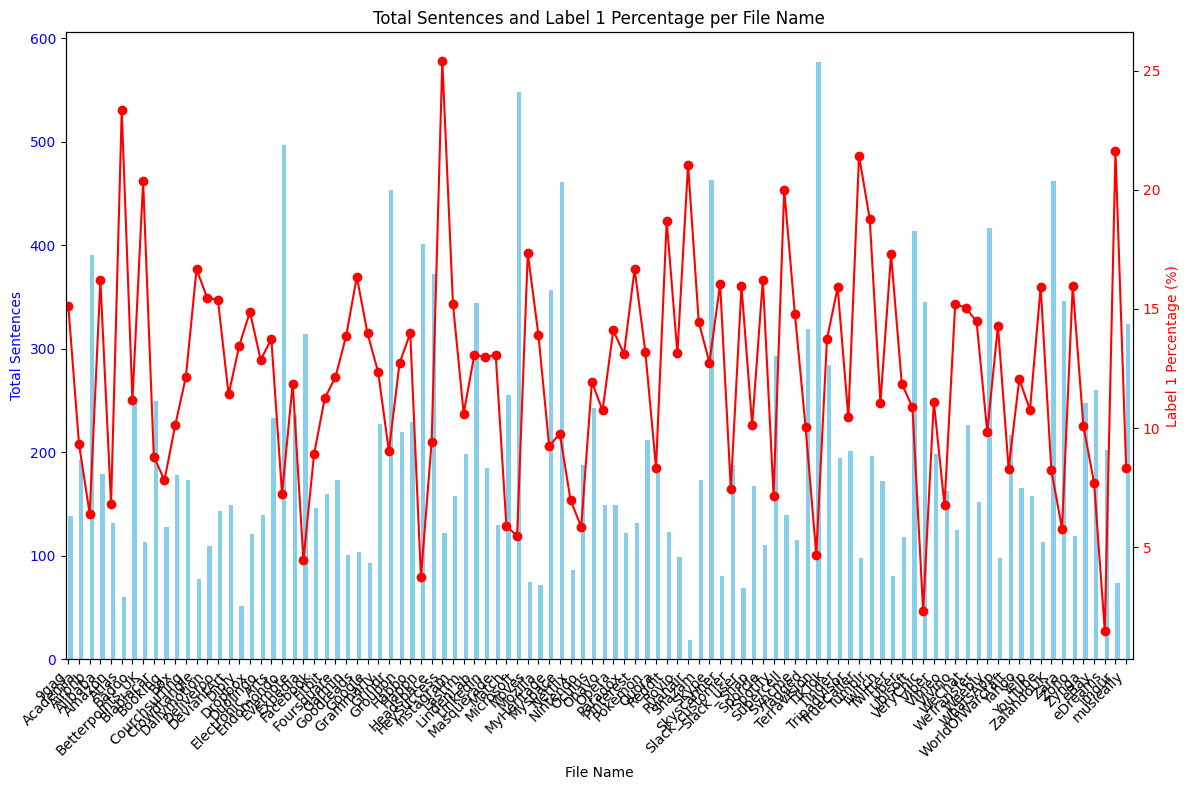

In [11]:
# Calculate the total number of sentences per file_name
file_name_counts = data['file_name'].value_counts()

# Calculate the percentage of label being 1 for each file_name
label_1_percentages = data[data['label'] == 1]['file_name'].value_counts() / file_name_counts * 100

# Combine the results into a DataFrame for visualization
file_name_stats = pd.DataFrame({
    'Total Sentences': file_name_counts,
    'Label 1 Percentage': label_1_percentages
}).sort_index()

# Plot the results
fig, ax1 = plt.subplots(figsize=(12, 8))

# Bar plot for total sentences
file_name_stats['Total Sentences'].plot(kind='bar', color='skyblue', ax=ax1, position=0, width=0.4, label='Total Sentences')
ax1.set_ylabel('Total Sentences', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('File Name')
ax1.set_xticks(range(len(file_name_stats.index)))
ax1.set_xticklabels(file_name_stats.index, rotation=45, ha='right')

# Line plot for label 1 percentage
ax2 = ax1.twinx()
file_name_stats['Label 1 Percentage'].plot(kind='line', color='red', marker='o', ax=ax2, label='Label 1 Percentage')
ax2.set_ylabel('Label 1 Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a title and legend
plt.title('Total Sentences and Label 1 Percentage per File Name')
fig.tight_layout()
plt.show()

In [12]:
unique_file_names_count = data['file_name'].nunique()
print("Number of unique labels in 'file_name' column:", unique_file_names_count)

Number of unique labels in 'file_name' column: 100


In [18]:
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import coo_matrix
import numpy as np

# Vectorize the text column
vectorizer = CountVectorizer()
term_matrix = vectorizer.fit_transform(data['text'])

# Compute co-occurrence matrix
co_occurrence = (term_matrix.T @ term_matrix).tocsc()

# Compute term frequencies
term_frequencies = np.array(term_matrix.sum(axis=0)).flatten()

# Total number of terms
total_terms = term_frequencies.sum()

# Compute Pointwise Mutual Information (PMI)
pmi_matrix = co_occurrence.copy()
rows, cols = co_occurrence.nonzero()
for i, j in zip(rows, cols):
    joint_prob = co_occurrence[i, j] / total_terms
    prob_i = term_frequencies[i] / total_terms
    prob_j = term_frequencies[j] / total_terms
    pmi_matrix[i, j] = np.log2(joint_prob / (prob_i * prob_j))

# Compute statistics for PMI values
pmi_values = pmi_matrix.data
lmi_stats = {
    'min': np.min(pmi_values),
    'max': np.max(pmi_values),
    'mean': np.mean(pmi_values),
    'std': np.std(pmi_values)
}
print("LMI Statistics:", lmi_stats)

LMI Statistics: {'min': np.int64(-1), 'max': np.int64(19), 'mean': np.float64(7.002733199288212), 'std': np.float64(2.877515436366146)}


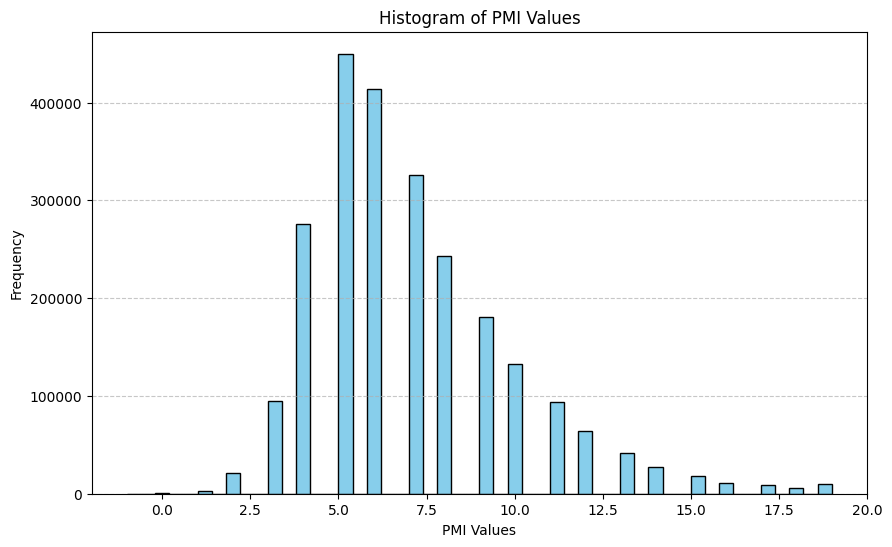

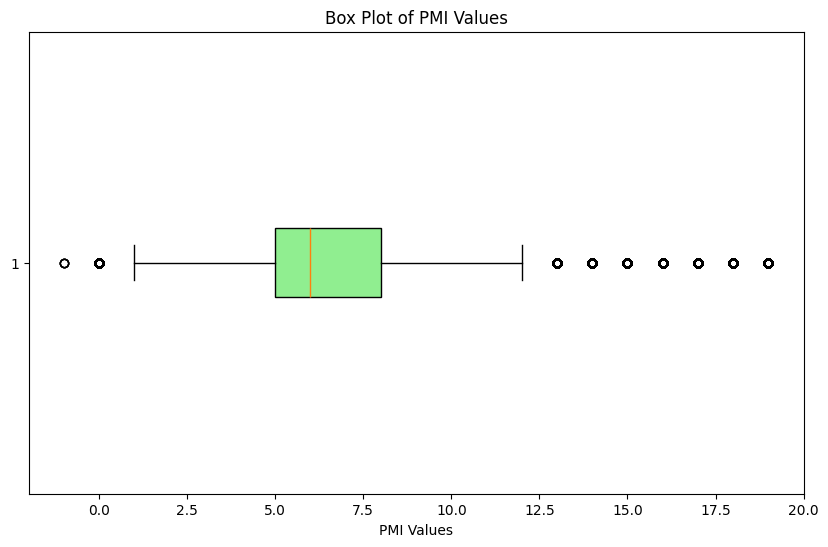

In [19]:
# Plot histogram of PMI values
plt.figure(figsize=(10, 6))
plt.hist(pmi_values, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('PMI Values')
plt.ylabel('Frequency')
plt.title('Histogram of PMI Values')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot box plot of PMI values
plt.figure(figsize=(10, 6))
plt.boxplot(pmi_values, vert=False, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.xlabel('PMI Values')
plt.title('Box Plot of PMI Values')
plt.show()

In [61]:
unique_labels = data['label'].unique()
print("Unique labels:", unique_labels)

Unique labels: [0 1]


,id,file_name,label,label_type,text,label_indices
2,2,Mozilla,1,['USE'],by accessing or signing up to receive communic...,[9]
37,37,Mozilla,1,['CR'],you understand and agree that mozilla reserves...,[3]
49,49,Mozilla,1,['TER'],we may suspend or terminate your access to our...,[8]
57,57,Mozilla,1,['LTD'],"except as required by law , mozilla and the in...",[6]


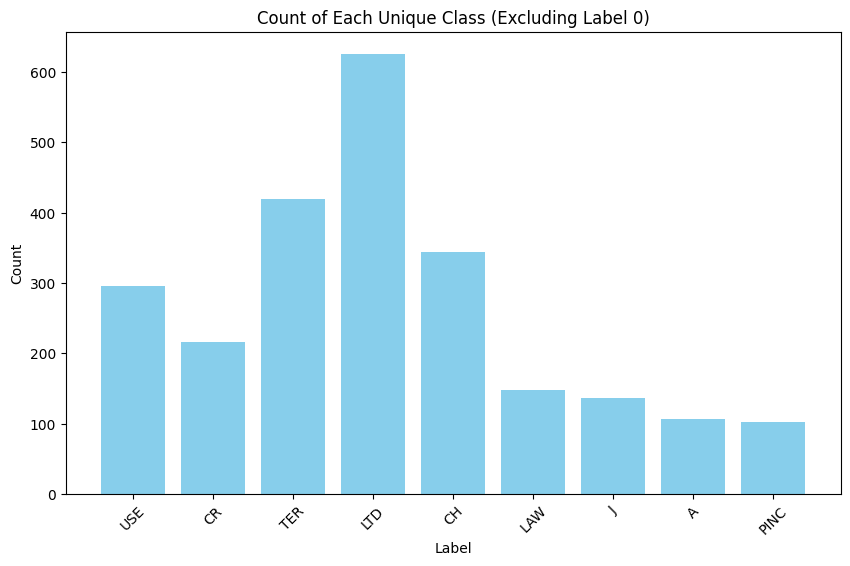

In [64]:
# Mapping of numeric labels to text labels
label_mapping = {1: 'A', 2: 'CH', 3: 'CR', 4: 'J', 5: 'LAW', 6: 'LTD', 7: 'PINC', 8: 'TER', 9: 'USE'}

# Replace numeric labels with text labels
filtered_counts_text = {label_mapping[label]: count for label, count in label_counts.items() if label in label_mapping}

# Plot the graph
plt.figure(figsize=(10, 6))
plt.bar(filtered_counts_text.keys(), filtered_counts_text.values(), color='skyblue')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Count of Each Unique Class (Excluding Label 0)')
plt.xticks(rotation=45)
plt.show()


In [34]:
unique_labels = data['label_type'].unique()
print("Unique labels:", unique_labels)
len(unique_labels)

Unique labels: ['[]' "['USE']" "['CR']" "['TER']" "['LTD']" "['CH']" "['LAW']" "['J']"
 "['A']" "['CR', 'TER']" "['LTD', 'TER']" "['CH', 'LTD', 'TER']"
 "['PINC', 'USE']" "['J', 'LAW']" "['PINC']" "['CH', 'TER']"
 "['CH', 'USE']" "['CH', 'LTD']" "['CR', 'LTD']" "['CH', 'CR']"
 "['A', 'LAW']" "['CH', 'LAW']" "['CH', 'PINC', 'USE']"]


23

In [35]:
unique_labels = data['label_indices'].unique()
print("Unique labels:", unique_labels)
len(unique_labels)

Unique labels: ['[0]' '[9]' '[3]' '[8]' '[6]' '[2]' '[5]' '[4]' '[1]' '[3, 8]' '[6, 8]'
 '[2, 6, 8]' '[7, 9]' '[4, 5]' '[7]' '[2, 8]' '[2, 9]' '[2, 6]' '[3, 6]'
 '[2, 3]' '[1, 5]' '[2, 5]' '[2, 7, 9]']


23

In [25]:
# Compute descriptive statistics for the "data" table
data_stats = data.describe(include='all')
print(data_stats)

                  id    file_name         label label_type  \
count   20417.000000        20417  20417.000000      20417   
unique           NaN          100           NaN         28   
top              NaN  Terravision           NaN         []   
freq             NaN          577           NaN      18239   
mean    10208.000000          NaN      0.106872        NaN   
std      5894.024559          NaN      0.308958        NaN   
min         0.000000          NaN      0.000000        NaN   
25%      5104.000000          NaN      0.000000        NaN   
50%     10208.000000          NaN      0.000000        NaN   
75%     15312.000000          NaN      0.000000        NaN   
max     20416.000000          NaN      1.000000        NaN   

                                                     text label_indices  
count                                               20417         20417  
unique                                              19915            28  
top     our notice to you will be

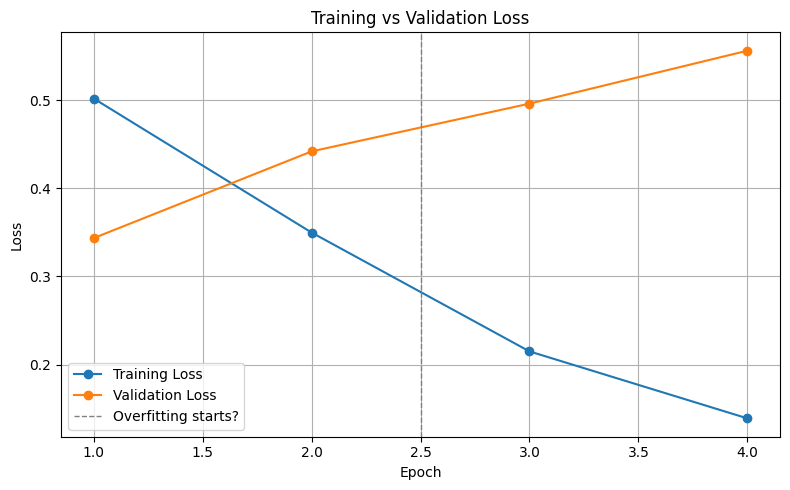

In [15]:
import matplotlib.pyplot as plt

# Epochs
epochs = [1, 2, 3, 4]

# Loss values
training_loss = [0.501900, 0.349800, 0.214900, 0.138900]
validation_loss = [0.343603, 0.442002, 0.496226, 0.556292]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(epochs, training_loss, marker='o', label='Training Loss')
plt.plot(epochs, validation_loss, marker='o', label='Validation Loss')

# Annotating possible overfitting
plt.axvline(x=2.5, color='gray', linestyle='--', linewidth=1, label='Overfitting starts?')

# Labels and title
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = [1, 2, 3, 4]

# Metrics
accuracy = [0.888214, 0.936839, 0.941068, 0.939482]
f1_score = [0.610856, 0.703106, 0.729040, 0.721072]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy, marker='o', label='Accuracy', color='green')
plt.plot(epochs, f1_score, marker='o', label='F1 Score', color='purple')

# Labels and title
plt.title("Accuracy and F1 Score Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0.5, 1.0)  # Set range for better comparison
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
